# Customer Churn

## Customer Churn Prediction

### Problem

Customer churn represents a major challenge for subscription-based businesses. Identifying customers at risk of leaving allows companies to take proactive actions to improve retention and reduce revenue loss.

The objective of this project is to predict the probability of customer churn using machine learning techniques.

---

### 📊 Dataset

The dataset used is the IBM Telco Customer Churn dataset, which contains information about:

- Customer demographics  
- Services subscribed  
- Account information  
- Churn status  

---

### Methodology

The project follows these steps:

1. Exploratory Data Analysis (EDA)  
2. Data cleaning and preprocessing  
3. Feature encoding (One-Hot Encoding and Ordinal Encoding)  
4. Model training using Logistic Regression  
5. Handling class imbalance using `class_weight`  
6. Threshold tuning to improve churn detection  
7. Model evaluation using classification metrics and ROC-AUC  

---

### Results

- ROC-AUC: ~0.83  
- Improved recall for churn detection through threshold adjustment  
- Balanced performance between precision and recall  

The model shows a strong ability to identify customers at risk of churn.

---

### Key Insights

- Customers with month-to-month contracts show higher churn rates  
- Higher monthly charges are associated with increased churn risk  
- Lack of additional services (e.g., tech support) may increase churn probability  

---

###  Conclusion

The model can be used as a base for implementing customer retention strategies focused on high-risk users.

It prioritizes recall to reduce the number of missed churn cases, aligning with business impact.

The model can be further improved with additional data and features.

In [1]:
import pandas as pd 
import numpy as np

In [2]:
df = pd.read_csv("Customer_Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


## 1. EDA (distribution, important variables, insight)

In [3]:
# It's crutial to note the data type of the most important features.
# The relevant variables are: Tenures, Monthly charge and contract.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Very important to observe if there's any noise or useless values inside our data set e.g NaN.
df.isna().any()

customerID          False
gender              False
SeniorCitizen       False
Partner             False
Dependents          False
tenure              False
PhoneService        False
MultipleLines       False
InternetService     False
OnlineSecurity      False
OnlineBackup        False
DeviceProtection    False
TechSupport         False
StreamingTV         False
StreamingMovies     False
Contract            False
PaperlessBilling    False
PaymentMethod       False
MonthlyCharges      False
TotalCharges        False
Churn               False
dtype: bool

In [5]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

#### 📊 Key Variables Analysis

##### 🕒 Tenure
Customers with less time with the company presents more churn.

##### 💰 Monthly Charges
Higher Monthly charges without clear incentives are related to mare churn.

##### 🔒 Contract
Monthly payments are in greater risk.

##### 🔧 Tech Support
Quality of service and technical support are important for the expirience of cx's.

##### 💸 Payment Method
Habits that could creat friction to stay with us.

##### 💻 Internet Service
Expirience of our services.

**Insight:** New customers, high costs and short time contracts are the clearer features to study and train our model with.

## 2. Cleaning and preparation

In [6]:
cols_2_drop = ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'StreamingTV', 'StreamingMovies', 
               'DeviceProtection', 'PaperlessBilling', 'TotalCharges']

df = df.drop(columns=cols_2_drop)

In [7]:
df

,tenure,InternetService,TechSupport,Contract,PaymentMethod,MonthlyCharges,Churn
0,1,DSL,No,Month-to-month,Electronic check,29.85,No
1,34,DSL,No,One year,Mailed check,56.95,No
2,2,DSL,No,Month-to-month,Mailed check,53.85,Yes
3,45,DSL,Yes,One year,Bank transfer (automatic),42.30,No
4,2,Fiber optic,No,Month-to-month,Electronic check,70.70,Yes
...,...,...,...,...,...,...,...
7038,24,DSL,Yes,One year,Mailed check,84.80,No
7039,72,Fiber optic,No,One year,Credit card (automatic),103.20,No
7040,11,DSL,No,Month-to-month,Electronic check,29.60,No
7041,4,Fiber optic,No,Month-to-month,Mailed check,74.40,Yes


##### It's necessary to transform our categorical variables to an understandable format for our model.

In [8]:
df = pd.get_dummies(df, columns=["InternetService"], drop_first=True)
df = pd.get_dummies(df, columns=["TechSupport"], drop_first=True)
df = pd.get_dummies(df, columns=["PaymentMethod"], drop_first=True)

In [9]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [10]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(categories=[[
    "Month-to-month", "One year", "Two year"
]])

df[["Contract"]] = encoder.fit_transform(df[["Contract"]])

In [11]:
df

,tenure,Contract,MonthlyCharges,Churn,InternetService_Fiber optic,InternetService_No,TechSupport_No internet service,TechSupport_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0.0,29.85,No,False,False,False,False,False,True,False
1,34,1.0,56.95,No,False,False,False,False,False,False,True
2,2,0.0,53.85,Yes,False,False,False,False,False,False,True
3,45,1.0,42.30,No,False,False,False,True,False,False,False
4,2,0.0,70.70,Yes,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
7038,24,1.0,84.80,No,False,False,False,True,False,False,True
7039,72,1.0,103.20,No,True,False,False,False,True,False,False
7040,11,0.0,29.60,No,False,False,False,False,False,True,False
7041,4,0.0,74.40,Yes,True,False,False,False,False,False,True


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   tenure                                 7043 non-null   int64  
 1   Contract                               7043 non-null   float64
 2   MonthlyCharges                         7043 non-null   float64
 3   Churn                                  7043 non-null   object 
 4   InternetService_Fiber optic            7043 non-null   bool   
 5   InternetService_No                     7043 non-null   bool   
 6   TechSupport_No internet service        7043 non-null   bool   
 7   TechSupport_Yes                        7043 non-null   bool   
 8   PaymentMethod_Credit card (automatic)  7043 non-null   bool   
 9   PaymentMethod_Electronic check         7043 non-null   bool   
 10  PaymentMethod_Mailed check             7043 non-null   bool   
dtypes: b

##### There still the dependant variable (churn) and transforming the bool objects to int.

In [13]:
df["Churn"] = df["Churn"].map({
    "No": 0, 
    "Yes": 1
})

In [14]:
df = df.astype(int)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   tenure                                 7043 non-null   int64
 1   Contract                               7043 non-null   int64
 2   MonthlyCharges                         7043 non-null   int64
 3   Churn                                  7043 non-null   int64
 4   InternetService_Fiber optic            7043 non-null   int64
 5   InternetService_No                     7043 non-null   int64
 6   TechSupport_No internet service        7043 non-null   int64
 7   TechSupport_Yes                        7043 non-null   int64
 8   PaymentMethod_Credit card (automatic)  7043 non-null   int64
 9   PaymentMethod_Electronic check         7043 non-null   int64
 10  PaymentMethod_Mailed check             7043 non-null   int64
dtypes: int64(11)
memory usage: 605

In [16]:
df

,tenure,Contract,MonthlyCharges,Churn,InternetService_Fiber optic,InternetService_No,TechSupport_No internet service,TechSupport_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,29,0,0,0,0,0,0,1,0
1,34,1,56,0,0,0,0,0,0,0,1
2,2,0,53,1,0,0,0,0,0,0,1
3,45,1,42,0,0,0,0,1,0,0,0
4,2,0,70,1,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
7038,24,1,84,0,0,0,0,1,0,0,1
7039,72,1,103,0,1,0,0,0,1,0,0
7040,11,0,29,0,0,0,0,0,0,1,0
7041,4,0,74,1,1,0,0,0,0,0,1


##### To finish with preparation, we separate the train and test set.

In [17]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_, y_test = train_test_split(X, y, test_size = 0.4, random_state=137)

## 3. ML model creation

In [19]:
from sklearn.linear_model import LogisticRegression

CxCh = LogisticRegression(max_iter = 1000)
CxCh.fit(X_train, y_train_)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## 4. Model evaluation

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = CxCh.predict(X_test)
y_prob = CxCh.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      2050
           1       0.65      0.47      0.55       768

    accuracy                           0.79      2818
   macro avg       0.74      0.69      0.70      2818
weighted avg       0.78      0.79      0.78      2818

ROC-AUC: 0.8336166158536585


##### Results are acceptable, but may be missleading and highlight opportunities for improvement.

The main problem lies in the recall of the Churn class, which is low and limits the model's ability to correctly identify customers who abandon the service. Furthermore, the imbalance in the data makes metrics such as the weighted average give a more favorable impression than the performance on the minority class actually reflects.

##### It is recommended to adjust the threshold and analyze how the generalization of the model change to improve the detection of churn cases.

In [21]:
probabilidades = [0.2, 0.3, 0.4, 0.55, 0.6]

for l in probabilidades:
    y_prob = CxCh.predict_proba(X_test)[:, 1]
    y_pred_l = (y_prob > l).astype(int)
    print(f"\n Threshold: {l}")
    print(classification_report(y_test, y_pred_l))


 Threshold: 0.2
              precision    recall  f1-score   support

           0       0.91      0.67      0.77      2050
           1       0.48      0.83      0.61       768

    accuracy                           0.71      2818
   macro avg       0.70      0.75      0.69      2818
weighted avg       0.80      0.71      0.73      2818


 Threshold: 0.3
              precision    recall  f1-score   support

           0       0.89      0.77      0.82      2050
           1       0.55      0.75      0.63       768

    accuracy                           0.76      2818
   macro avg       0.72      0.76      0.73      2818
weighted avg       0.80      0.76      0.77      2818


 Threshold: 0.4
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      2050
           1       0.61      0.61      0.61       768

    accuracy                           0.79      2818
   macro avg       0.73      0.73      0.73      2818
weighted avg       0.79

By evaluating different decision thresholds and observing a point of maximum efficiency between recall and accuracy, a decision threshold of 0.3 was selected, prioritizing the detection of at-risk customers, aligned with the business impact.

##### We could also try other options of training for the model that penalizes incorrect churn predictions more:

In [22]:
CxCh = LogisticRegression(class_weight={0:1, 1:2}, max_iter=1000)
CxCh.fit(X_train, y_train_)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,"{0: 1, 1: 2}"
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [23]:
y_pred = CxCh.predict(X_test)
y_prob = CxCh.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.88      0.80      0.84      2050
           1       0.57      0.71      0.63       768

    accuracy                           0.78      2818
   macro avg       0.73      0.76      0.74      2818
weighted avg       0.80      0.78      0.78      2818

ROC-AUC: 0.8333047510162601


##### We perform the same exploratory exercise involving testing with different decision thresholds:

In [24]:
probabilidades = [0.2, 0.3, 0.4, 0.55, 0.6]

for l in probabilidades:
    y_prob = CxCh.predict_proba(X_test)[:, 1]
    y_pred_l = (y_prob > l).astype(int)
    print(f"\n Threshold: {l}")
    print(classification_report(y_test, y_pred_l))


 Threshold: 0.2
              precision    recall  f1-score   support

           0       0.95      0.52      0.67      2050
           1       0.42      0.93      0.58       768

    accuracy                           0.63      2818
   macro avg       0.68      0.72      0.62      2818
weighted avg       0.80      0.63      0.64      2818


 Threshold: 0.3
              precision    recall  f1-score   support

           0       0.91      0.64      0.75      2050
           1       0.47      0.84      0.60       768

    accuracy                           0.69      2818
   macro avg       0.69      0.74      0.68      2818
weighted avg       0.79      0.69      0.71      2818


 Threshold: 0.4
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      2050
           1       0.51      0.79      0.62       768

    accuracy                           0.73      2818
   macro avg       0.70      0.75      0.70      2818
weighted avg       0.79

## 5. Metric visualization

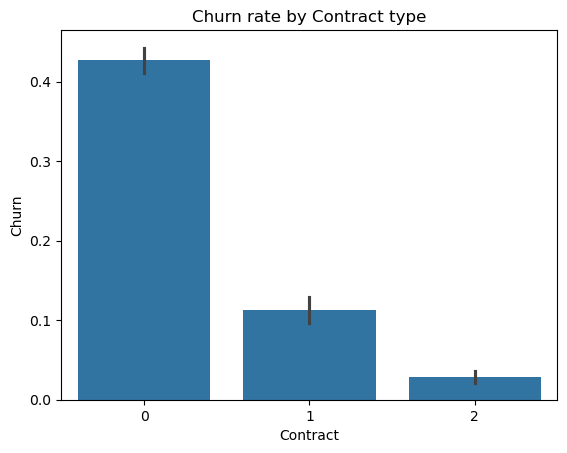

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="Contract", y="Churn", data=df)
plt.title("Churn rate by Contract type")
plt.show()

##### Observation:
There is a clear tendency towards churn if the contract type is "Month-to-month". Similarly, there is a considerable number of employees in the other two options that are well worth retaining.

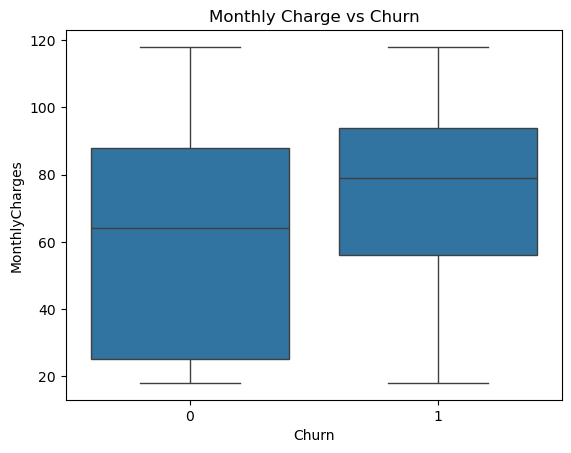

In [26]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charge vs Churn")
plt.show()

##### Observation:
Customers with higher monthly charges tend to churn.

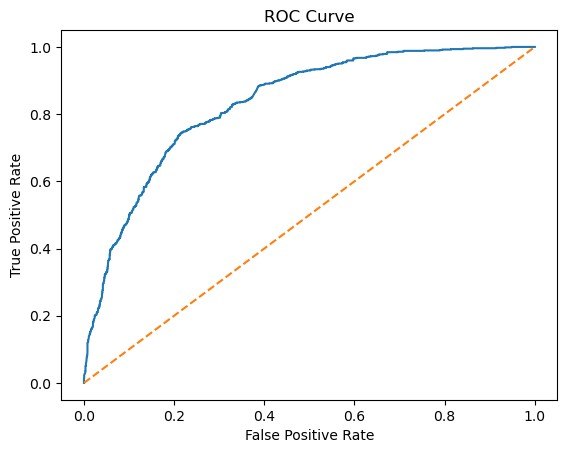

In [27]:
from sklearn.metrics import roc_curve

fpr,tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

##### Observation:
Note how the curve is significantly higher than the diagonal, indicating that the model has a good balance between detecting churn and avoiding false positives.

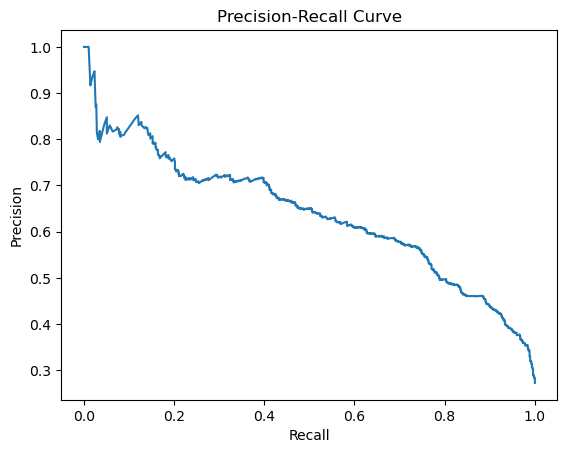

In [28]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

##### Observation:
The graph shows the relationship between recall and accuracy. As recall increases, model accuracy decreases. Specifically, we observe that the curve is steepest for a recall between 0.7 and 0.8 (where accuracy is 0.5–0.6), and this is where the decision threshold should be set (as presented).

## 6. Conclusions

##### 🤖 Model:
The logistic regression model with class weighting allows the identification of customers at risk of churn based on variables such as contract type, service costs, and customer characteristics (services and payment method).

##### Class imbalance and thresholds ⚙️:
Due to the lower representation of churn cases compared to the total, there was some difficulty in detecting customers at risk of leaving. To mitigate this issue, a higher penalty was applied to misclassifying churn cases, and the decision threshold was adjusted to optimize both the model and the decision-making process.

##### Recall 📈:
As a result of the adjustments for class imbalance and threshold tuning, the model sacrifices some precision. However, this is done to avoid losing customers, given the high impact it represents for the company.

##### Relationships 📊:
Some clearly identified patterns are:

- Customers with month-to-month contracts show higher churn.
- Higher monthly charges are associated with greater churn.

##### This concludes this practical data science project.
##### This model can serve as a foundation for implementing retention strategies focused on high-risk customers, and it can be further improved with a larger volume of data and additional features.
